In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\dorot\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv('./df_final.csv')

In [3]:
df.head()

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,...,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION,TZ_NAME,LOCAL_TIME,Hour,DayOfWeek,CLUSTER_K4
0,A6184793,C7717436,T8535582,0.99,2024-03-13 06:46:55+00:00,Spend,OH,EUCLID,OH,WESTLAKE,...,29,Card Not Present,112,WENDYS,0,America/New_York,2024-03-13 02:46:55,2,Wednesday,1
1,A2296562,C5518346,T2383075,22.76,2024-05-16 20:34:18+00:00,Spend,MI,FORT GRATIOT,MI,FORT GRATIOT,...,87,Card Present,214,JIMMY JOHNS GOURMET SANDWICHES,2,America/New_York,2024-05-16 16:34:18,16,Thursday,0
2,A5523719,C7179772,T7494465,8.84,2024-04-25 17:09:37+00:00,Spend,OH,TOLEDO,OH,TOLEDO,...,25,Card Present,58,SUBWAY,0,America/New_York,2024-04-25 13:09:37,13,Thursday,1
3,A7905524,C1779514,T5897261,8.78,2024-05-26 13:50:06+00:00,Spend,IN,LAFAYETTE,IN,LAFAYETTE,...,26,Card Not Present,37,MCDONALDS,0,America/New_York,2024-05-26 09:50:06,9,Sunday,0
4,A7846687,C8240547,T2709494,18.01,2024-05-05 19:54:35+00:00,Spend,MN,DELANO,MN,DELANO,...,10,Card Present,522,CULVERS,0,America/Chicago,2024-05-05 14:54:35,14,Sunday,1


In [4]:
df['CLUSTER_K4'].value_counts()

CLUSTER_K4
1    1660985
2    1295535
3    1099068
0     583532
Name: count, dtype: int64

In [5]:
cluster_size = df.groupby('CLUSTER_K4')['ACCOUNT_ID'].nunique().sort_index()
cluster_ratio = (cluster_size / cluster_size.sum() * 100).round(2)

pd.DataFrame({
    'customer_count': cluster_size,
    'ratio_%': cluster_ratio
})

,customer_count,ratio_%
CLUSTER_K4,,
0,465002,12.73
1,1241529,33.98
2,960944,26.30
3,985972,26.99


In [6]:
cat_col = 'CARD_TYPE'

ct = pd.crosstab(df['CLUSTER_K4'], df[cat_col])
ct_ratio = pd.crosstab(df['CLUSTER_K4'], df[cat_col], normalize='index') * 100

print(ct)
print(ct_ratio.round(2))

CARD_TYPE   Benefit - Health  Credit    Debit  General Purpose  Payroll
CLUSTER_K4                                                             
0                          2  263948   319573                9        0
1                         69  229245  1428841              740     2090
2                          0  255188  1038401             1822      124
3                         14  243670   853756              761      867
CARD_TYPE   Benefit - Health  Credit  Debit  General Purpose  Payroll
CLUSTER_K4                                                           
0                        0.0   45.23  54.77             0.00     0.00
1                        0.0   13.80  86.02             0.04     0.13
2                        0.0   19.70  80.15             0.14     0.01
3                        0.0   22.17  77.68             0.07     0.08


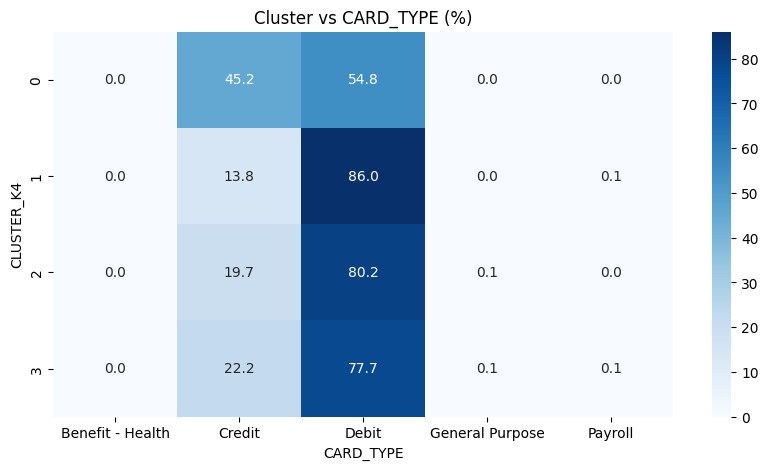

In [7]:
plt.figure(figsize=(10, 5))
sns.heatmap(ct_ratio, annot=True, fmt='.1f', cmap='Blues')
plt.title(f'Cluster vs {cat_col} (%)')
plt.xlabel(cat_col)
plt.ylabel('CLUSTER_K4')
plt.show()

In [ ]:
# 컬럼명 설정
cluster_col = 'CLUSTER_K4'
card_col = 'CARD_TYPE'
cust_col = 'ACCOUNT_ID'

# 분석용 데이터
tmp = df[[cluster_col, card_col, cust_col]].dropna().copy()

# 카드명 통일(선택)
tmp[card_col] = tmp[card_col].astype(str).str.strip()

# 1) 군집별 총 거래건수
cluster_txn_count = (
    tmp.groupby(cluster_col)
       .size()
       .rename('TOTAL_TXN')
       .to_frame()
)

In [ ]:
# 2) 군집별 신용/체크 절대 건수
cluster_card_count = (
    tmp.groupby([cluster_col, card_col])
       .size()
       .unstack(fill_value=0)
)

# 비율 계산
cluster_card_ratio = (
    cluster_card_count.div(cluster_card_count.sum(axis=1), axis=0) * 100
).round(2)

cluster_card_ratio.columns = [f'{col}_RATIO(%)' for col in cluster_card_ratio.columns]

In [ ]:
# 3) 고객 단위 평균 신용카드 비중
# 'Credit'인 경우 1, 아니면 0
tmp['IS_CREDIT'] = (tmp[card_col] == 'Credit').astype(int)

# 고객별 신용카드 사용비중
cust_credit_share = (
    tmp.groupby([cluster_col, cust_col])['IS_CREDIT']
       .mean()
       .reset_index(name='CUST_CREDIT_SHARE')
)

# 군집별로 고객 평균/중앙값/고객수
cluster_cust_credit = (
    cust_credit_share.groupby(cluster_col)['CUST_CREDIT_SHARE']
    .agg(
        CUSTOMER_AVG_CREDIT_SHARE='mean',
        CUSTOMER_MEDIAN_CREDIT_SHARE='median',
        N_CUSTOMERS='count'
    )
)

cluster_cust_credit[['CUSTOMER_AVG_CREDIT_SHARE', 'CUSTOMER_MEDIAN_CREDIT_SHARE']] *= 100
cluster_cust_credit = cluster_cust_credit.round(2)


In [ ]:
# 최종 요약표
summary_table = (
    cluster_txn_count
    .join(cluster_card_count)
    .join(cluster_card_ratio)
    .join(cluster_cust_credit)
)

print("=== 군집별 카드 사용 요약 ===")
display(summary_table)

=== 군집별 카드 사용 요약 ===


,TOTAL_TXN,Benefit - Health,Credit,Debit,General Purpose,Payroll,Benefit - Health_RATIO(%),Credit_RATIO(%),Debit_RATIO(%),General Purpose_RATIO(%),Payroll_RATIO(%),CUSTOMER_AVG_CREDIT_SHARE,CUSTOMER_MEDIAN_CREDIT_SHARE,N_CUSTOMERS
CLUSTER_K4,,,,,,,,,,,,,,
0,583532,2,263948,319573,9,0,0.0,45.23,54.77,0.00,0.00,46.85,0.0,465002
1,1660985,69,229245,1428841,740,2090,0.0,13.80,86.02,0.04,0.13,15.01,0.0,1241529
2,1295535,0,255188,1038401,1822,124,0.0,19.70,80.15,0.14,0.01,21.18,0.0,960944
3,1099068,14,243670,853756,761,867,0.0,22.17,77.68,0.07,0.08,22.58,0.0,985972


In [14]:
df['CARD_PRESENT_INDICATOR'].value_counts(dropna=False)

CARD_PRESENT_INDICATOR
Card Present        3381806
Unknown              679071
Card Not Present     578243
Name: count, dtype: int64

CARD_PRESENT_INDICATOR  Card Not Present  Card Present  Unknown
CLUSTER_K4                                                     
0                                  16.43         74.54     9.04
1                                  11.79         73.19    15.02
2                                  12.26         70.73    17.01
3                                  11.63         74.13    14.23


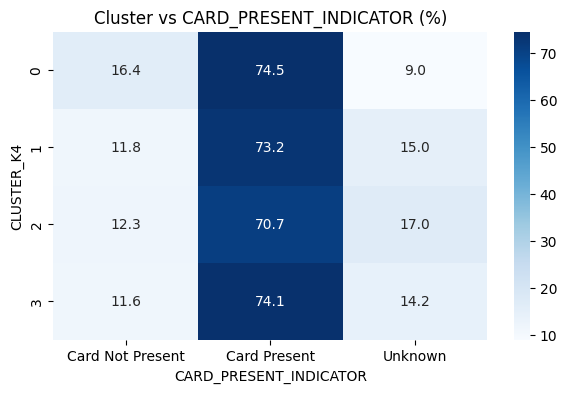

In [15]:
cluster_col = 'CLUSTER_K4'
present_col = 'CARD_PRESENT_INDICATOR'

ct = pd.crosstab(df[cluster_col], df[present_col], normalize='index') * 100
print(ct.round(2))

plt.figure(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues')
plt.title('Cluster vs CARD_PRESENT_INDICATOR (%)')
plt.xlabel('CARD_PRESENT_INDICATOR')
plt.ylabel(cluster_col)
plt.show()

=== 전체 기준: 카드타입별 Present / Not Present 비중(%) ===


CARD_PRESENT_INDICATOR,Card Not Present,Card Present
CARD_TYPE,,
Credit,18.21,81.79
Debit,13.50,86.50


=== 전체 기준: 카드타입별 Card Not Present 비중(%) ===


CARD_PRESENT_INDICATOR,CNP_%
CARD_TYPE,
Credit,18.21
Debit,13.50


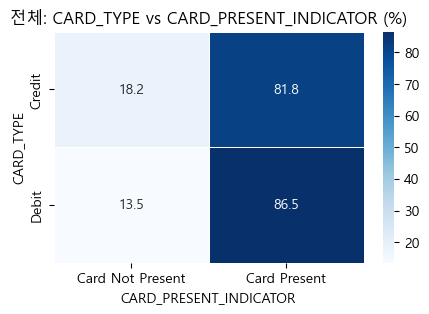

In [ ]:
card_col = 'CARD_TYPE'
present_col = 'CARD_PRESENT_INDICATOR'
cluster_col = 'CLUSTER_K4'

tmp = df[[cluster_col, card_col, present_col]].dropna().copy()

tmp = tmp[
    tmp[card_col].isin(['Credit', 'Debit']) &
    tmp[present_col].isin(['Card Present', 'Card Not Present'])   # Unknown 제외
].copy()

# 1) 전체 비교
overall_ratio = (
    pd.crosstab(tmp[card_col], tmp[present_col], normalize='index') * 100
).round(2)

print("=== 전체 기준: 카드타입별 Present / Not Present 비중(%) ===")
display(overall_ratio)

# Card Not Present 비중
overall_cnp = overall_ratio[['Card Not Present']].rename(
    columns={'Card Not Present': 'CNP_%'}
)
print("=== 전체 기준: 카드타입별 Card Not Present 비중(%) ===")
display(overall_cnp)

plt.figure(figsize=(5, 3))
sns.heatmap(overall_ratio, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white')
plt.title('전체: CARD_TYPE vs CARD_PRESENT_INDICATOR (%)')
plt.xlabel('CARD_PRESENT_INDICATOR')
plt.ylabel('CARD_TYPE')
plt.show()

=== 군집별 + 카드타입별 Present / Not Present 비중(%) ===


CARD_PRESENT_INDICATOR  Card Not Present  Card Present
CLUSTER_K4 CARD_TYPE                                  
0          Credit                  18.51         81.49
           Debit                   17.65         82.35
1          Credit                  17.24         82.76
           Debit                   13.28         86.72
2          Credit                  19.73         80.27
           Debit                   13.36         86.64
3          Credit                  17.20         82.80
           Debit                   12.41         87.59

=== 군집별 카드타입의 Card Not Present 비중(%) ===


CARD_TYPE,Credit,Debit
CLUSTER_K4,,
0,18.51,17.65
1,17.24,13.28
2,19.73,13.36
3,17.20,12.41


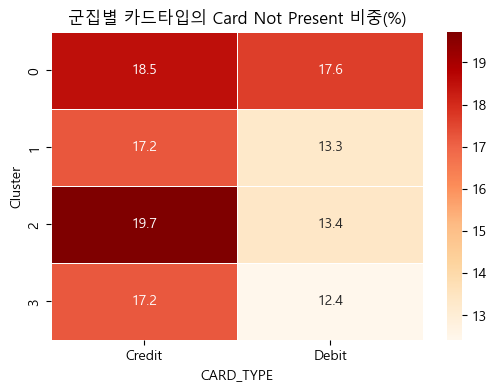

In [ ]:
# 2) 군집별 비교
cluster_ratio = (
    pd.crosstab(
        [tmp[cluster_col], tmp[card_col]],
        tmp[present_col],
        normalize='index'
    ) * 100
).round(2)

print("=== 군집별 + 카드타입별 Present / Not Present 비중(%) ===")
display(cluster_ratio)

# 군집별 Card Not Present 비중
cluster_cnp = cluster_ratio['Card Not Present'].unstack().round(2)

print("=== 군집별 카드타입의 Card Not Present 비중(%) ===")
display(cluster_cnp)

plt.figure(figsize=(6, 4))
sns.heatmap(cluster_cnp, annot=True, fmt='.1f', cmap='OrRd',
            linewidths=0.5, linecolor='white')
plt.title('군집별 카드타입의 Card Not Present 비중(%)')
plt.xlabel('CARD_TYPE')
plt.ylabel('Cluster')
plt.show()

=== 군집별 (Credit CNP% - Debit CNP%) ===


CARD_TYPE,Credit_minus_Debit
CLUSTER_K4,
0,0.86
1,3.96
2,6.37
3,4.79


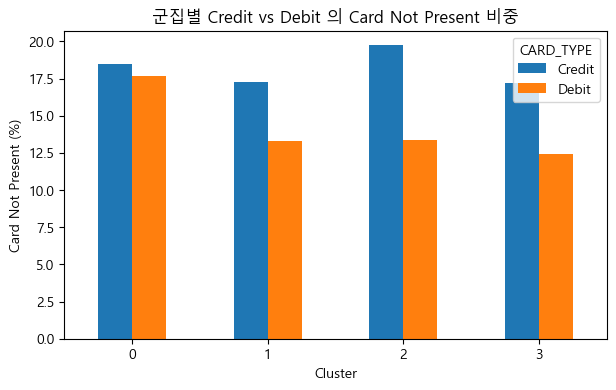

In [ ]:
# 3) Credit - Debit 차이
cluster_cnp['Credit_minus_Debit'] = (
    cluster_cnp['Credit'] - cluster_cnp['Debit']
).round(2)

print("=== 군집별 (Credit CNP% - Debit CNP%) ===")
display(cluster_cnp[['Credit_minus_Debit']])

# 막대그래프
cluster_cnp[['Credit', 'Debit']].plot(kind='bar', figsize=(7,4))
plt.title('군집별 Credit vs Debit 의 Card Not Present 비중')
plt.xlabel('Cluster')
plt.ylabel('Card Not Present (%)')
plt.xticks(rotation=0)
plt.legend(title='CARD_TYPE')
plt.show()

In [ ]:
import warnings
import platform

warnings.filterwarnings('ignore')
# 한글 폰트 설정
# =========================
system_name = platform.system()

if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False


cluster_col = 'CLUSTER_K4'
hour_col = 'Hour'              
weekday_col = 'DayOfWeek'        

# 데이터 정리
plot_df = df[[cluster_col, hour_col, weekday_col]].copy()

plot_df[hour_col] = pd.to_numeric(plot_df[hour_col], errors='coerce')
plot_df = plot_df.dropna(subset=[cluster_col, hour_col, weekday_col]).copy()

plot_df[hour_col] = plot_df[hour_col].astype(int)
plot_df = plot_df[(plot_df[hour_col] >= 0) & (plot_df[hour_col] <= 23)]

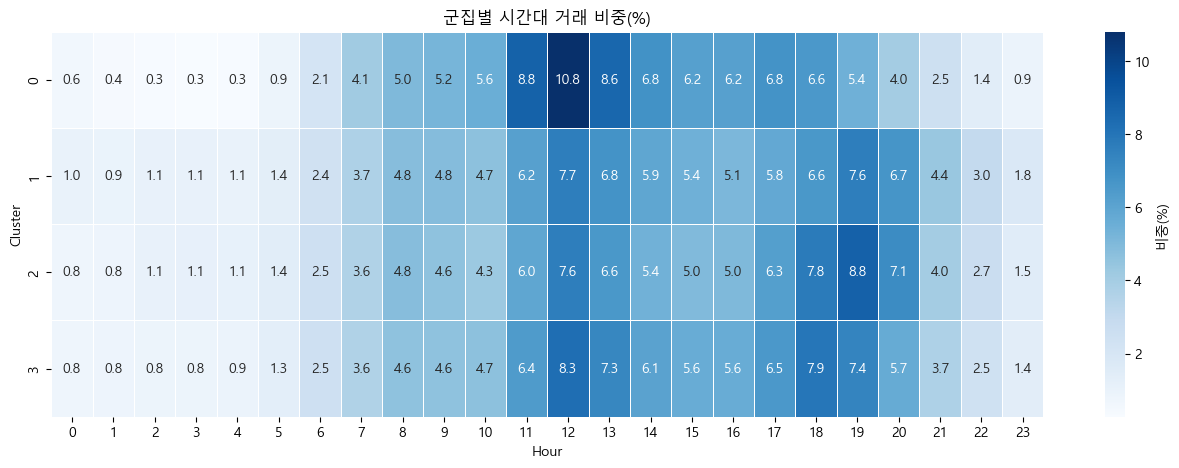

=== 군집별 시간대 거래 비중(%) ===


Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CLUSTER_K4,,,,,,,,,,,,,,,,,,,,,
0,0.60,0.42,0.32,0.27,0.32,0.87,2.14,4.14,5.03,5.25,...,6.84,6.22,6.19,6.80,6.56,5.43,4.02,2.51,1.45,0.90
1,1.03,0.93,1.08,1.08,1.05,1.38,2.38,3.69,4.81,4.85,...,5.93,5.43,5.11,5.82,6.58,7.64,6.73,4.38,2.98,1.83
2,0.75,0.83,1.07,1.14,1.11,1.45,2.49,3.64,4.82,4.62,...,5.41,4.98,5.01,6.27,7.77,8.83,7.09,4.02,2.71,1.50
3,0.80,0.82,0.85,0.85,0.92,1.31,2.47,3.62,4.63,4.63,...,6.08,5.64,5.63,6.54,7.93,7.41,5.68,3.69,2.45,1.39


In [ ]:
# 1) 군집별 시간대 거래 비중
hour_order = list(range(24))

cluster_hour_count = (
    plot_df.groupby([cluster_col, hour_col])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=hour_order, fill_value=0)
)

cluster_hour_ratio = (
    cluster_hour_count.div(cluster_hour_count.sum(axis=1), axis=0) * 100
).round(2)

plt.figure(figsize=(16, 5))
sns.heatmap(
    cluster_hour_ratio,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '비중(%)'}
)
plt.title('군집별 시간대 거래 비중(%)')
plt.xlabel('Hour')
plt.ylabel('Cluster')
plt.show()

print("=== 군집별 시간대 거래 비중(%) ===")
display(cluster_hour_ratio)

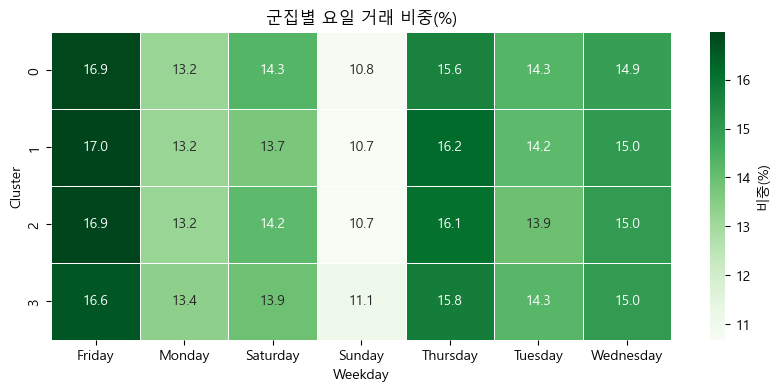

=== 군집별 요일 거래 비중(%) ===


DayOfWeek,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
CLUSTER_K4,,,,,,,
0,16.91,13.17,14.31,10.78,15.61,14.31,14.91
1,16.98,13.18,13.72,10.68,16.23,14.18,15.03
2,16.95,13.17,14.19,10.68,16.07,13.95,14.99
3,16.61,13.38,13.92,11.07,15.75,14.26,15.01


In [ ]:
# 2) 군집별 요일 거래 비중
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 실제 데이터에 없는 값이 들어가면 자동으로 빠질 수 있으니 교집합만 사용
weekday_order = [d for d in weekday_order if d in plot_df[weekday_col].astype(str).unique()]

plot_df[weekday_col] = plot_df[weekday_col].astype(str)

cluster_weekday_count = (
    plot_df.groupby([cluster_col, weekday_col])
           .size()
           .unstack(fill_value=0)
)

if len(weekday_order) > 0:
    cluster_weekday_count = cluster_weekday_count.reindex(columns=weekday_order, fill_value=0)

cluster_weekday_ratio = (
    cluster_weekday_count.div(cluster_weekday_count.sum(axis=1), axis=0) * 100
).round(2)

plt.figure(figsize=(10, 4))
sns.heatmap(
    cluster_weekday_ratio,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '비중(%)'}
)
plt.title('군집별 요일 거래 비중(%)')
plt.xlabel('Weekday')
plt.ylabel('Cluster')
plt.show()

print("=== 군집별 요일 거래 비중(%) ===")
display(cluster_weekday_ratio)

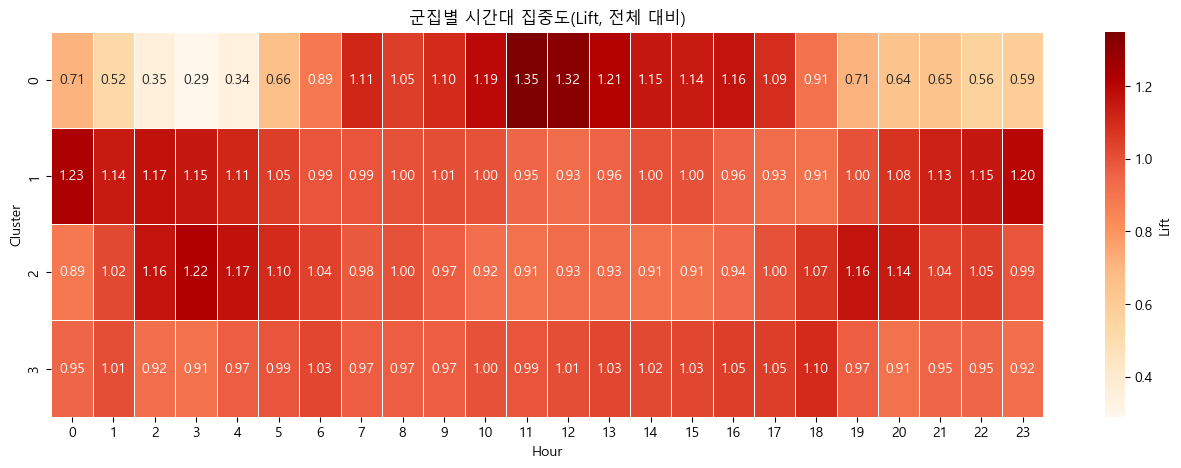

=== 군집별 시간대 Lift ===


Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CLUSTER_K4,,,,,,,,,,,,,,,,,,,,,
0,0.71,0.52,0.35,0.29,0.34,0.66,0.89,1.11,1.05,1.10,...,1.15,1.14,1.16,1.09,0.91,0.71,0.64,0.65,0.56,0.59
1,1.23,1.14,1.17,1.15,1.11,1.05,0.99,0.99,1.00,1.01,...,1.00,1.00,0.96,0.93,0.91,1.00,1.08,1.13,1.15,1.20
2,0.89,1.02,1.16,1.22,1.17,1.10,1.04,0.98,1.00,0.97,...,0.91,0.91,0.94,1.00,1.07,1.16,1.14,1.04,1.05,0.99
3,0.95,1.01,0.92,0.91,0.97,0.99,1.03,0.97,0.97,0.97,...,1.02,1.03,1.05,1.05,1.10,0.97,0.91,0.95,0.95,0.92


In [ ]:
# 3) 전체 대비 상대 집중도(lift)
overall_hour_ratio = (plot_df[hour_col].value_counts(normalize=True)
                      .sort_index()
                      .reindex(hour_order, fill_value=0) * 100)

hour_lift = (cluster_hour_ratio / overall_hour_ratio.replace(0, np.nan)).round(2)

plt.figure(figsize=(16, 5))
sns.heatmap(
    hour_lift,
    annot=True,
    fmt='.2f',
    cmap='OrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Lift'}
)
plt.title('군집별 시간대 집중도(Lift, 전체 대비)')
plt.xlabel('Hour')
plt.ylabel('Cluster')
plt.show()

print("=== 군집별 시간대 Lift ===")
display(hour_lift)

In [23]:
df['CARD_HOLDER_GENERATION'].value_counts()

CARD_HOLDER_GENERATION
Millennial     1841253
Gen X          1251207
Gen Z           793346
Baby Boomer     684335
Silent           20208
Name: count, dtype: int64

CLUSTER_K4
1    3615896
Name: count, dtype: int64


CARD_HOLDER_GENERATION,Gen Z,Millennial,Gen X,Baby Boomer,Silent
CLUSTER_K4,,,,,
0,44372,177533,158542,83041,1486
1,311443,462256,257509,187377,6541
2,108566,400784,306390,131089,3612
3,136611,368699,278184,185825,6037


CARD_HOLDER_GENERATION,Gen Z,Millennial,Gen X,Baby Boomer,Silent
CLUSTER_K4,,,,,
0,9.54,38.18,34.10,17.86,0.32
1,25.42,37.73,21.02,15.29,0.53
2,11.42,42.17,32.24,13.79,0.38
3,14.01,37.80,28.52,19.05,0.62


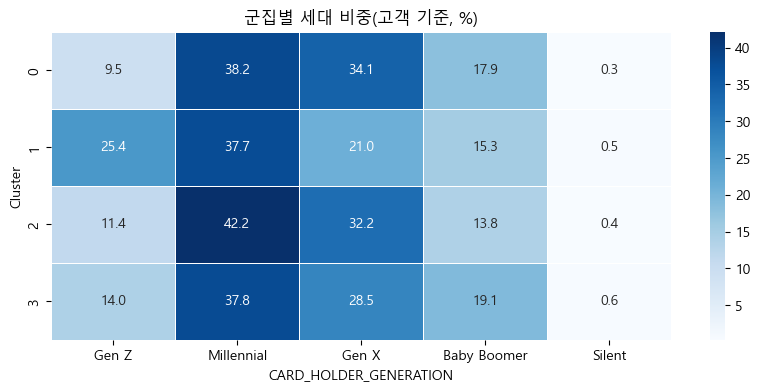

In [25]:
cluster_col = 'CLUSTER_K4'
cust_col = 'ACCOUNT_ID'
gen_col = 'CARD_HOLDER_GENERATION'

# 고객당 1행만 남기기
cust_gen = df[[cluster_col, cust_col, gen_col]].dropna().drop_duplicates()

# 혹시 같은 고객이 여러 군집에 들어갔는지 체크
print(cust_gen.groupby(cust_col)[cluster_col].nunique().value_counts())

# 세대 순서
gen_order = ['Gen Z', 'Millennial', 'Gen X', 'Baby Boomer', 'Silent']
gen_order = [g for g in gen_order if g in cust_gen[gen_col].unique()]

# 군집별 세대 비중
gen_count = pd.crosstab(cust_gen[cluster_col], cust_gen[gen_col])
gen_count = gen_count.reindex(columns=gen_order, fill_value=0)

gen_ratio = (gen_count.div(gen_count.sum(axis=1), axis=0) * 100).round(2)

display(gen_count)
display(gen_ratio)

plt.figure(figsize=(10, 4))
sns.heatmap(gen_ratio, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white')
plt.title('군집별 세대 비중(고객 기준, %)')
plt.xlabel('CARD_HOLDER_GENERATION')
plt.ylabel('Cluster')
plt.show()

In [28]:
df['MERCHANT_CATEGORY_LEVEL_1'].value_counts()

MERCHANT_CATEGORY_LEVEL_1
Restaurants and Food Services    4013976
Retail                            325106
Consumer Services                  81492
Travel and Leisure                 12064
Services                            7680
Financial Services                   651
Technology / Media / Telecom         345
Package Shipping Logistics            14
Specialty Retailers                   10
Commercial Equipment                  10
Media & Advertising                    1
Name: count, dtype: int64

In [29]:
df['MERCHANT_CATEGORY_LEVEL_2'].value_counts()

MERCHANT_CATEGORY_LEVEL_2
QSR                                        2666019
Casual Dining                               908232
Vending & Beverage Retailers                528737
Food Services                               101834
General Retail                               89985
Payment Services                             81655
Grocery and Delivery                         19340
Food Delivery                                12601
Leisure                                       9904
Business Services                             7616
Specialty Retailers                           3834
Home Improvement and Furnishing               2227
Nutrition & Vitamin Retailers                 2081
Gas / Convenience                             1976
Department Stores                             1282
Travel                                        1203
Transportation                                 600
Apparel, Accessories, and Footwear             468
Lodging                                        296
Media

MERCHANT_CATEGORY_LEVEL_2,QSR,Casual Dining,Vending & Beverage Retailers,Food Services,General Retail,Payment Services,Grocery and Delivery,Food Delivery,Leisure,Business Services,Specialty Retailers,Home Improvement and Furnishing
CLUSTER_K4,,,,,,,,,,,,
0,61.60,20.03,10.21,2.78,2.52,1.44,0.52,0.13,0.47,0.10,0.12,0.08
1,58.45,20.20,13.94,2.14,1.84,2.12,0.45,0.36,0.18,0.20,0.08,0.04
2,60.28,20.48,11.71,2.36,2.17,1.76,0.45,0.27,0.19,0.20,0.08,0.05
3,61.82,21.20,10.05,2.21,1.91,1.73,0.35,0.26,0.19,0.14,0.09,0.06


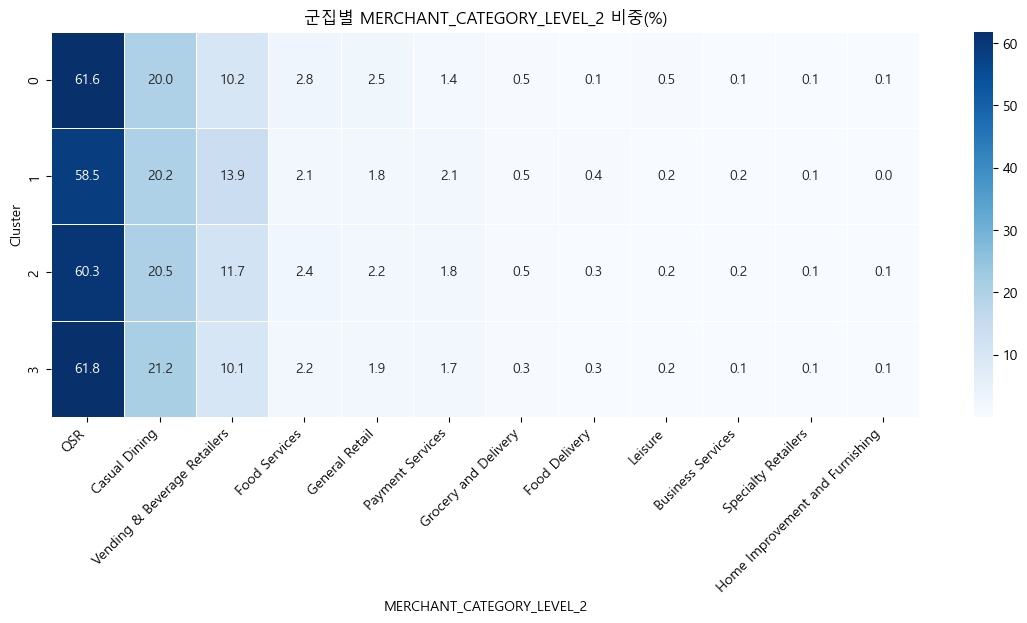

In [30]:
cluster_col = 'CLUSTER_K4'
mcc_col = 'MERCHANT_CATEGORY_LEVEL_2'

tmp = df[[cluster_col, mcc_col]].dropna().copy()
tmp[mcc_col] = tmp[mcc_col].astype(str).str.strip()

# 상위 12개만 보기
top_n = 12
top_cats = tmp[mcc_col].value_counts().head(top_n).index.tolist()

tmp_top = tmp[tmp[mcc_col].isin(top_cats)].copy()

# 군집별 비중
ratio = (
    pd.crosstab(tmp_top[cluster_col], tmp_top[mcc_col], normalize='index') * 100
).round(2)

ratio = ratio.reindex(columns=top_cats, fill_value=0)

display(ratio)

plt.figure(figsize=(14, 5))
sns.heatmap(ratio, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white')
plt.title('군집별 MERCHANT_CATEGORY_LEVEL_2 비중(%)')
plt.xlabel('MERCHANT_CATEGORY_LEVEL_2')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.show()

MERCHANT_CATEGORY_LEVEL_2,QSR,Casual Dining,Vending & Beverage Retailers,Food Services,General Retail,Payment Services,Grocery and Delivery,Food Delivery,Leisure,Business Services,Specialty Retailers,Home Improvement and Furnishing
CLUSTER_K4,,,,,,,,,,,,
0,1.02,0.98,0.86,1.21,1.24,0.78,1.19,0.46,2.10,0.58,1.39,1.59
1,0.97,0.99,1.17,0.93,0.91,1.15,1.03,1.27,0.81,1.16,0.92,0.80
2,1.00,1.00,0.98,1.03,1.07,0.96,1.03,0.95,0.85,1.16,0.92,1.00
3,1.03,1.03,0.84,0.96,0.94,0.94,0.80,0.91,0.85,0.81,1.04,1.19


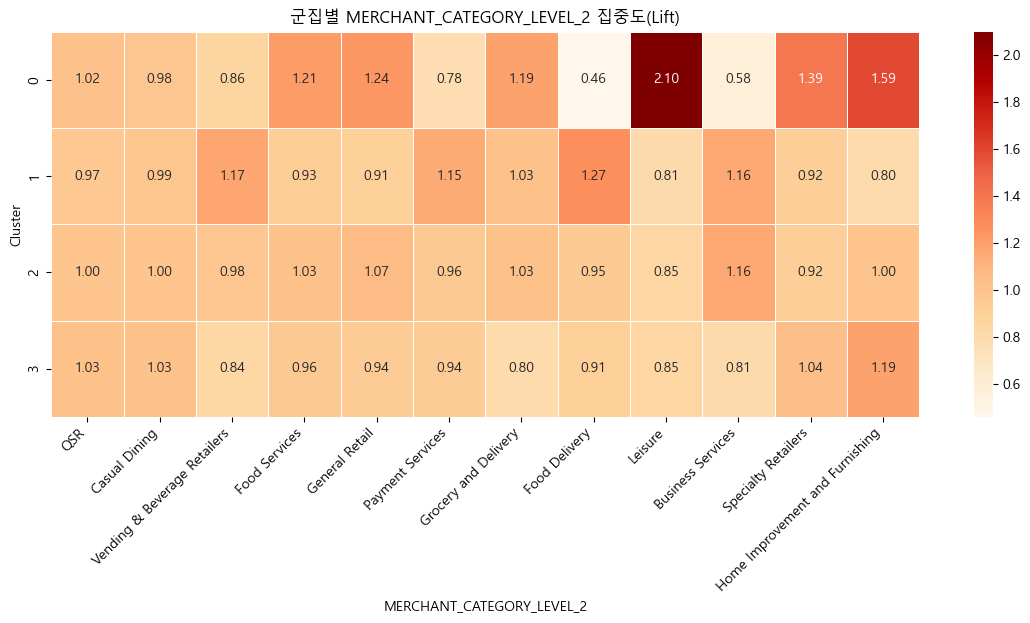

In [31]:
# 전체 대비 lift
overall_ratio = (
    tmp_top[mcc_col].value_counts(normalize=True) * 100
).reindex(ratio.columns)

lift = (ratio / overall_ratio.replace(0, pd.NA)).round(2)

display(lift)

plt.figure(figsize=(14, 5))
sns.heatmap(lift, annot=True, fmt='.2f', cmap='OrRd',
            linewidths=0.5, linecolor='white')
plt.title('군집별 MERCHANT_CATEGORY_LEVEL_2 집중도(Lift)')
plt.xlabel('MERCHANT_CATEGORY_LEVEL_2')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.show()

In [32]:
cluster_col = 'CLUSTER_K4'
cust_col = 'ACCOUNT_ID'
txn_cnt_col = 'CARD_HOLDER_TOTAL_TRANSACTION_COUNT'

# 고객 기준 1행만 남기기
tmp = (
    df[[cluster_col, cust_col, txn_cnt_col]]
    .dropna()
    .drop_duplicates(subset=[cust_col, cluster_col])
    .copy()
)

# 숫자형 변환
tmp[txn_cnt_col] = pd.to_numeric(tmp[txn_cnt_col], errors='coerce')
tmp = tmp.dropna(subset=[txn_cnt_col]).copy()

# 군집별 요약통계
summary = (
    tmp.groupby(cluster_col)[txn_cnt_col]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
)

q = (
    tmp.groupby(cluster_col)[txn_cnt_col]
    .quantile([0.25, 0.75])
    .unstack()
    .round(2)
)
q.columns = ['Q1', 'Q3']

summary = summary.join(q)

print("=== 군집별 거래횟수 요약 ===")
display(summary)

=== 군집별 거래횟수 요약 ===


,count,mean,median,std,min,max,Q1,Q3
CLUSTER_K4,,,,,,,,
0,465002,2532.53,1793.0,2310.77,208,31071,933.0,3364.0
1,1241529,1028.63,843.0,694.27,2,9650,516.0,1344.0
2,960944,3468.58,2934.0,177875.06,240,174360569,1981.0,4194.0
3,985972,1317.65,1115.0,862.60,25,13157,675.0,1741.0


In [33]:
# 전체 평균 대비 상대수준
overall_mean = tmp[txn_cnt_col].mean()
summary['MEAN_LIFT_vs_OVERALL'] = (summary['mean'] / overall_mean).round(2)

print("=== 전체 평균 대비 평균 거래횟수 비율 ===")
display(summary[['mean', 'median', 'MEAN_LIFT_vs_OVERALL']])

=== 전체 평균 대비 평균 거래횟수 비율 ===


,mean,median,MEAN_LIFT_vs_OVERALL
CLUSTER_K4,,,
0,2532.53,1793.0,1.31
1,1028.63,843.0,0.53
2,3468.58,2934.0,1.79
3,1317.65,1115.0,0.68


In [38]:
cluster_col = 'CLUSTER_K4'
cust_col = 'ACCOUNT_ID'
spend_col = 'CARD_HOLDER_TOTAL_SPEND'

tmp = (
    df[[cluster_col, cust_col, spend_col]]
    .dropna()
    .drop_duplicates(subset=[cust_col, cluster_col])
    .copy()
)

tmp[spend_col] = pd.to_numeric(tmp[spend_col], errors='coerce')
tmp = tmp.dropna(subset=[spend_col]).copy()

# 군집별 요약통계
summary_spend = (
    tmp.groupby(cluster_col)[spend_col]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
)

q = (
    tmp.groupby(cluster_col)[spend_col]
    .quantile([0.25, 0.75])
    .unstack()
    .round(2)
)
q.columns = ['Q1', 'Q3']

summary_spend = summary_spend.join(q)

print("=== 군집별 누적 지출금액 요약 ===")
display(summary_spend)

# 전체 평균 대비 상대수준
overall_mean = tmp[spend_col].mean()
summary_spend['MEAN_LIFT_vs_OVERALL'] = (
    summary_spend['mean'] / overall_mean
).round(2)

print("=== 전체 평균 대비 평균 누적 지출금액 비율 ===")
display(summary_spend[['mean', 'median', 'MEAN_LIFT_vs_OVERALL']])


=== 군집별 누적 지출금액 요약 ===


,count,mean,median,std,min,max,Q1,Q3
CLUSTER_K4,,,,,,,,
0,465002,136827.24,76515.17,1.717648e+05,3126.17,4.915402e+06,36812.54,163407.93
1,1241529,32289.37,27802.30,1.971074e+04,17.44,1.549236e+05,16763.41,43952.89
2,960944,279411.39,123370.33,1.273833e+08,12708.08,1.248710e+11,88411.23,177168.95
3,985972,60472.86,50972.08,4.248693e+04,1923.07,1.706860e+06,32105.27,77101.86


=== 전체 평균 대비 평균 누적 지출금액 비율 ===


,mean,median,MEAN_LIFT_vs_OVERALL
CLUSTER_K4,,,
0,136827.24,76515.17,1.16
1,32289.37,27802.30,0.27
2,279411.39,123370.33,2.36
3,60472.86,50972.08,0.51


=== 세대별 채널×시간대 비중(%) ===


CHANNEL_TIME,Offline_Morning,Offline_Lunch,Offline_Afternoon,Offline_Dinner,Offline_Night,Online_Morning,Online_Lunch,Online_Afternoon,Online_Dinner,Online_Night
CARD_HOLDER_GENERATION,,,,,,,,,,
Gen Z,14.33,12.56,15.75,25.13,15.62,3.59,3.01,3.23,3.50,3.28
Millennial,17.01,18.37,18.47,19.90,9.80,4.16,3.46,3.68,3.34,1.82
Gen X,18.11,22.52,21.60,19.20,6.23,3.17,2.86,3.08,2.49,0.73
Baby Boomer,19.68,27.06,24.58,16.00,3.71,2.31,2.24,2.44,1.67,0.31
Silent,19.67,30.10,26.24,13.11,2.59,1.75,1.90,2.00,2.32,0.31


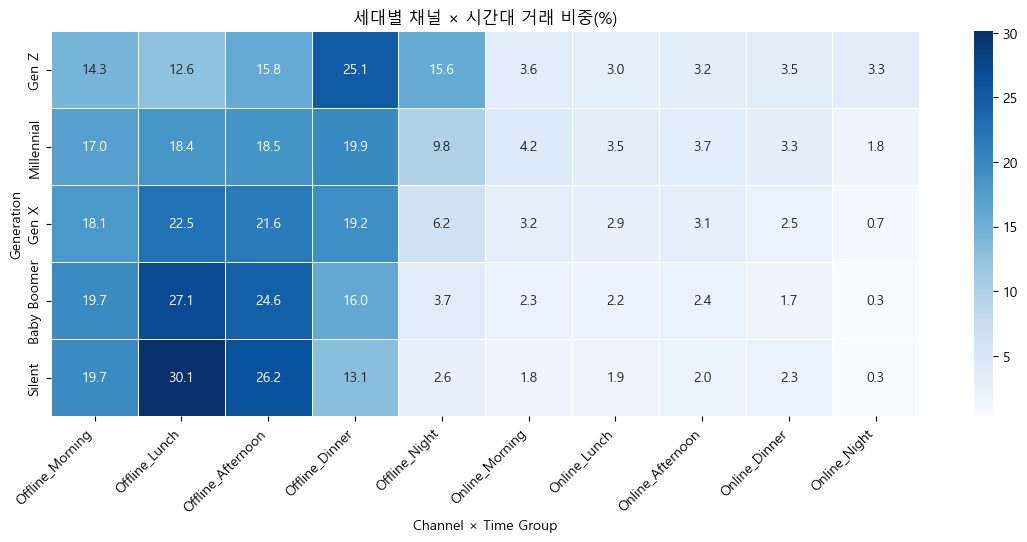

In [ ]:
gen_col = 'CARD_HOLDER_GENERATION'
present_col = 'CARD_PRESENT_INDICATOR'
hour_col = 'Hour'

# 필요한 컬럼만
tmp = df[[gen_col, present_col, hour_col]].dropna().copy()

# 시간 숫자형 변환
tmp[hour_col] = pd.to_numeric(tmp[hour_col], errors='coerce')
tmp = tmp.dropna(subset=[hour_col]).copy()
tmp[hour_col] = tmp[hour_col].astype(int)
tmp = tmp[(tmp[hour_col] >= 0) & (tmp[hour_col] <= 23)]

# Unknown 제외 + 채널 단순화
tmp = tmp[tmp[present_col].isin(['Card Present', 'Card Not Present'])].copy()
tmp['CHANNEL'] = tmp[present_col].map({
    'Card Present': 'Offline',
    'Card Not Present': 'Online'
})

# 시간대 구간화
def make_time_group(h):
    if 11 <= h <= 13:
        return 'Lunch'
    elif 18 <= h <= 21:
        return 'Dinner'
    elif 6 <= h <= 10:
        return 'Morning'
    elif 14 <= h <= 17:
        return 'Afternoon'
    else:
        return 'Night'

tmp['TIME_GROUP'] = tmp[hour_col].apply(make_time_group)

# 세대 순서
gen_order = ['Gen Z', 'Millennial', 'Gen X', 'Baby Boomer', 'Silent']
gen_order = [g for g in gen_order if g in tmp[gen_col].unique()]

# 1) 세대별 채널 × 시간대 비중
tmp['CHANNEL_TIME'] = tmp['CHANNEL'] + '_' + tmp['TIME_GROUP']

ratio = (
    pd.crosstab(tmp[gen_col], tmp['CHANNEL_TIME'], normalize='index') * 100
).round(2)

col_order = [
    'Offline_Morning', 'Offline_Lunch', 'Offline_Afternoon', 'Offline_Dinner', 'Offline_Night',
    'Online_Morning', 'Online_Lunch', 'Online_Afternoon', 'Online_Dinner', 'Online_Night'
]
col_order = [c for c in col_order if c in ratio.columns]

ratio = ratio.reindex(index=gen_order, columns=col_order, fill_value=0)

print("=== 세대별 채널×시간대 비중(%) ===")
display(ratio)

plt.figure(figsize=(14, 5))
sns.heatmap(ratio, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white')
plt.title('세대별 채널 × 시간대 거래 비중(%)')
plt.xlabel('Channel × Time Group')
plt.ylabel('Generation')
plt.xticks(rotation=45, ha='right')
plt.show()

=== 세대별 오프라인 시간대 분포(%) ===


TIME_GROUP,Morning,Lunch,Afternoon,Dinner,Night
CARD_HOLDER_GENERATION,,,,,
Gen Z,17.18,15.07,18.88,30.14,18.73
Millennial,20.36,21.98,22.10,23.82,11.73
Gen X,20.66,25.69,24.64,21.91,7.10
Baby Boomer,21.62,29.73,27.00,17.58,4.07
Silent,21.45,32.82,28.61,14.30,2.82


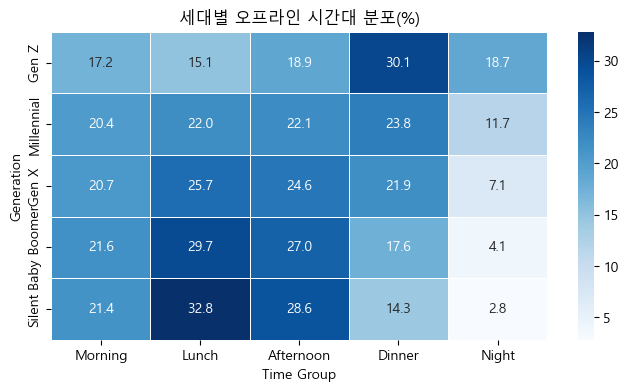

In [40]:
gen_col = 'CARD_HOLDER_GENERATION'
present_col = 'CARD_PRESENT_INDICATOR'
hour_col = 'Hour'

tmp = df[[gen_col, present_col, hour_col]].dropna().copy()
tmp[hour_col] = pd.to_numeric(tmp[hour_col], errors='coerce')
tmp = tmp.dropna(subset=[hour_col]).copy()
tmp[hour_col] = tmp[hour_col].astype(int)
tmp = tmp[(tmp[hour_col] >= 0) & (tmp[hour_col] <= 23)]

tmp = tmp[tmp[present_col].isin(['Card Present', 'Card Not Present'])].copy()
tmp['CHANNEL'] = tmp[present_col].map({
    'Card Present': 'Offline',
    'Card Not Present': 'Online'
})

def make_time_group(h):
    if 6 <= h <= 10:
        return 'Morning'
    elif 11 <= h <= 13:
        return 'Lunch'
    elif 14 <= h <= 17:
        return 'Afternoon'
    elif 18 <= h <= 21:
        return 'Dinner'
    else:
        return 'Night'

tmp['TIME_GROUP'] = tmp[hour_col].apply(make_time_group)

gen_order = ['Gen Z', 'Millennial', 'Gen X', 'Baby Boomer', 'Silent']
gen_order = [g for g in gen_order if g in tmp[gen_col].unique()]
time_order = ['Morning', 'Lunch', 'Afternoon', 'Dinner', 'Night']

# 오프라인만
offline = tmp[tmp['CHANNEL'] == 'Offline'].copy()
offline_ratio = (
    pd.crosstab(offline[gen_col], offline['TIME_GROUP'], normalize='index') * 100
).round(2)
offline_ratio = offline_ratio.reindex(index=gen_order, columns=time_order, fill_value=0)

print("=== 세대별 오프라인 시간대 분포(%) ===")
display(offline_ratio)

plt.figure(figsize=(8, 4))
sns.heatmap(offline_ratio, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white')
plt.title('세대별 오프라인 시간대 분포(%)')
plt.xlabel('Time Group')
plt.ylabel('Generation')
plt.show()

=== 세대별 온라인 시간대 분포(%) ===


TIME_GROUP,Morning,Lunch,Afternoon,Dinner,Night
CARD_HOLDER_GENERATION,,,,,
Gen Z,21.63,18.10,19.46,21.05,19.76
Millennial,25.30,21.01,22.35,20.30,11.04
Gen X,25.71,23.16,25.00,20.20,5.93
Baby Boomer,25.79,24.99,27.17,18.57,3.49
Silent,21.12,22.93,24.11,28.05,3.78


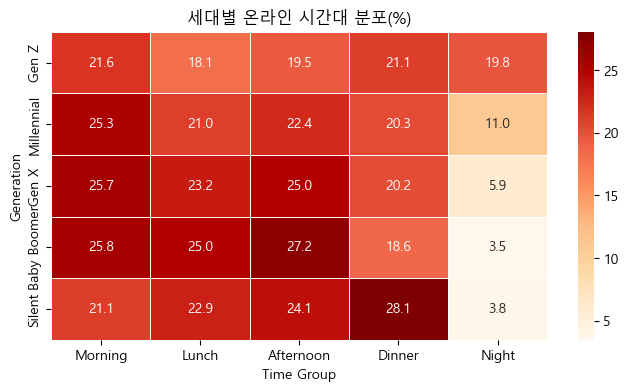

In [41]:
# 온라인만
online = tmp[tmp['CHANNEL'] == 'Online'].copy()
online_ratio = (
    pd.crosstab(online[gen_col], online['TIME_GROUP'], normalize='index') * 100
).round(2)
online_ratio = online_ratio.reindex(index=gen_order, columns=time_order, fill_value=0)

print("=== 세대별 온라인 시간대 분포(%) ===")
display(online_ratio)

plt.figure(figsize=(8, 4))
sns.heatmap(online_ratio, annot=True, fmt='.1f', cmap='OrRd',
            linewidths=0.5, linecolor='white')
plt.title('세대별 온라인 시간대 분포(%)')
plt.xlabel('Time Group')
plt.ylabel('Generation')
plt.show()

In [42]:
tmp = df[[gen_col, present_col, hour_col]].dropna().copy()
tmp[hour_col] = pd.to_numeric(tmp[hour_col], errors='coerce')
tmp = tmp.dropna(subset=[hour_col]).copy()
tmp[hour_col] = tmp[hour_col].astype(int)
tmp = tmp[(tmp[hour_col] >= 0) & (tmp[hour_col] <= 23)]
tmp = tmp[tmp[present_col] == 'Card Not Present'].copy()

def make_time_group(h):
    if 6 <= h <= 10:
        return 'Morning'
    elif 11 <= h <= 13:
        return 'Lunch'
    elif 14 <= h <= 17:
        return 'Afternoon'
    elif 18 <= h <= 21:
        return 'Dinner'
    else:
        return 'Night'

tmp['TIME_GROUP'] = tmp[hour_col].apply(make_time_group)

count_table = pd.crosstab(tmp[gen_col], tmp['TIME_GROUP'])
ratio_table = (count_table.div(count_table.sum(axis=1), axis=0) * 100).round(2)

print("=== 세대별 온라인 시간대 건수 ===")
display(count_table)

print("=== 세대별 온라인 시간대 비중(%) ===")
display(ratio_table)

print("=== Silent 온라인 총 건수 ===")
print(count_table.loc['Silent'].sum())

=== 세대별 온라인 시간대 건수 ===


TIME_GROUP,Afternoon,Dinner,Lunch,Morning,Night
CARD_HOLDER_GENERATION,,,,,
Baby Boomer,14974,10235,13776,14214,1921
Gen X,33337,26935,30884,34286,7913
Gen Z,20959,22670,19491,23292,21282
Millennial,58001,52681,54526,65670,28639
Silent,306,356,291,268,48


=== 세대별 온라인 시간대 비중(%) ===


TIME_GROUP,Afternoon,Dinner,Lunch,Morning,Night
CARD_HOLDER_GENERATION,,,,,
Baby Boomer,27.17,18.57,24.99,25.79,3.49
Gen X,25.00,20.20,23.16,25.71,5.93
Gen Z,19.46,21.05,18.10,21.63,19.76
Millennial,22.35,20.30,21.01,25.30,11.04
Silent,24.11,28.05,22.93,21.12,3.78


=== Silent 온라인 총 건수 ===
1269


In [ ]:
# 필요한 컬럼명
gen_col = 'CARD_HOLDER_GENERATION'
present_col = 'CARD_PRESENT_INDICATOR'
hour_col = 'Hour'
mcc2_col = 'MERCHANT_CATEGORY_LEVEL_2'

# Silent + Online + Dinner 추출
silent_online_dinner = df[
    (df[gen_col] == 'Silent') &
    (df[present_col] == 'Card Not Present') &
    (df[hour_col].between(18, 21))
][[mcc2_col]].dropna()

# 업종 분포
silent_dist = silent_online_dinner[mcc2_col].value_counts().to_frame('COUNT')
silent_dist['RATIO_%'] = (silent_dist['COUNT'] / silent_dist['COUNT'].sum() * 100).round(2)

print("=== Silent + Online + Dinner 업종 분포 ===")
display(silent_dist.head(15))

=== Silent + Online + Dinner 업종 분포 ===


,COUNT,RATIO_%
MERCHANT_CATEGORY_LEVEL_2,,
QSR,192,56.47
Casual Dining,134,39.41
Food Services,7,2.06
General Retail,5,1.47
Vending & Beverage Retailers,2,0.59


In [ ]:
industry_col = 'MERCHANT_CATEGORY_LEVEL_2'  

# 데이터 정리
plot_df = df[[industry_col]].copy()
plot_df[industry_col] = plot_df[industry_col].astype(str).str.strip()
plot_df = plot_df.dropna(subset=[industry_col])
plot_df = plot_df[plot_df[industry_col] != '']

# 업종별 거래 건수 / 비율 계산
industry_summary = (
    plot_df[industry_col]
    .value_counts(dropna=False)
    .rename_axis('업종')
    .reset_index(name='거래건수')
)

industry_summary['비율(%)'] = (
    industry_summary['거래건수'] / industry_summary['거래건수'].sum() * 100
).round(2)

print(industry_summary)

                                         업종     거래건수  비율(%)
0                                       QSR  2666019  60.03
1                             Casual Dining   908232  20.45
2              Vending & Beverage Retailers   528737  11.90
3                             Food Services   101834   2.29
4                            General Retail    89985   2.03
5                          Payment Services    81655   1.84
6                      Grocery and Delivery    19340   0.44
7                             Food Delivery    12601   0.28
8                                   Leisure     9904   0.22
9                         Business Services     7616   0.17
10                      Specialty Retailers     3834   0.09
11          Home Improvement and Furnishing     2227   0.05
12            Nutrition & Vitamin Retailers     2081   0.05
13                        Gas / Convenience     1976   0.04
14                        Department Stores     1282   0.03
15                                   Tra

In [ ]:
cluster_col = 'CLUSTER_K4'     
gen_col = 'CARD_HOLDER_GENERATION'      

# 1. 세대별 군집 비중표 (%)
gen_cluster_ratio = pd.crosstab(
    df[gen_col],
    df[cluster_col],
    normalize='index'  
) * 100

gen_cluster_ratio = gen_cluster_ratio.round(2)

print("세대별 군집 비중(%)")
display(gen_cluster_ratio)

세대별 군집 비중(%)


CLUSTER_K4,0,1,2,3
CARD_HOLDER_GENERATION,,,,
Baby Boomer,13.81,33.57,23.27,29.35
Gen X,15.80,26.98,32.46,24.77
Gen Z,7.41,53.89,19.37,19.32
Millennial,12.54,34.56,30.27,22.63
Silent,7.91,38.27,21.78,32.04


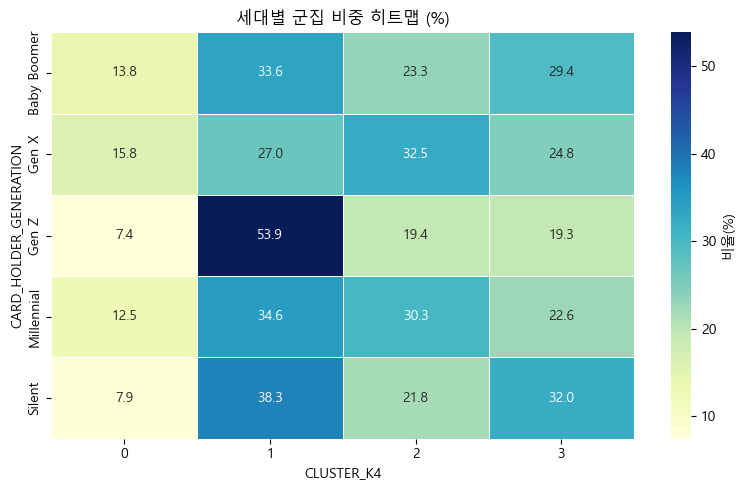

In [47]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    gen_cluster_ratio,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '비율(%)'}
)

plt.title('세대별 군집 비중 히트맵 (%)')
plt.xlabel('CLUSTER_K4')
plt.ylabel('CARD_HOLDER_GENERATION')
plt.tight_layout()
plt.show()

In [ ]:
cluster_col = 'CLUSTER_K4'
gen_col = 'CARD_HOLDER_GENERATION'
industry_col = 'MERCHANT_CATEGORY_LEVEL_3'  
region_col = 'CARD_HOLDER_STATE'                

# 3번 군집만 추출
c3 = df[df[cluster_col] == 3].copy()

# 업종 비중
c3_industry = (
    c3[industry_col]
    .value_counts(dropna=False)
    .reset_index()
)
c3_industry.columns = ['업종', '거래건수']
c3_industry['비율(%)'] = (
    c3_industry['거래건수'] / c3_industry['거래건수'].sum() * 100
).round(2)

display(c3_industry.head(20))

# 지역 비중
c3_region = (
    c3[region_col]
    .value_counts(dropna=False)
    .reset_index()
)
c3_region.columns = ['지역', '거래건수']
c3_region['비율(%)'] = (
    c3_region['거래건수'] / c3_region['거래건수'].sum() * 100
).round(2)

display(c3_region.head(20))

,업종,거래건수,비율(%)
0,QSR Burgers,316486,28.80
1,Coffee / Tea,114517,10.42
2,QSR Chicken,107868,9.81
3,Vending & Beverage Retailers,105551,9.60
4,Mexican Restaurants,81436,7.41
5,QSR Sandwiches,65443,5.95
6,NaN,46728,4.25
7,Breakfast Restaurants,44890,4.08
8,American Restaurants,44839,4.08
9,Pizza Restaurants,44662,4.06


,지역,거래건수,비율(%)
0,FL,92720,8.44
1,OH,87192,7.93
2,TX,84839,7.72
3,MI,66168,6.02
4,CA,65536,5.96
5,MN,48453,4.41
6,NC,46233,4.21
7,TN,45985,4.18
8,VA,43335,3.94
9,SC,43047,3.92


In [ ]:
# 군집별 업종 비중
industry_col = 'MERCHANT_CATEGORY_LEVEL_2'

# 군집별 업종 건수표
cluster_industry_count = pd.crosstab(df[cluster_col], df[industry_col])

# 군집 내 비중(%)
cluster_industry_ratio = pd.crosstab(
    df[cluster_col],
    df[industry_col],
    normalize='index'
) * 100

cluster_industry_ratio = cluster_industry_ratio.round(2)

display(cluster_industry_count)
display(cluster_industry_ratio)

MERCHANT_CATEGORY_LEVEL_2,"Apparel, Accessories, and Footwear",Auto Insurance,"Automobiles, Parts, Tires, and Services",Business Services,Casual Dining,Commercial Equipment,Consumer Services,DTC,Department Stores,Discount Retailers,...,Payment Services,Pet Care,Pharmacy,QSR,Specialty Retailers,Telecom,Transportation,Travel,Variety Retailers,Vending & Beverage Retailers
CLUSTER_K4,,,,,,,,,,,,,,,,,,,,,
0,101,13,2,545,111458,1,18,3,176,4,...,8005,51,5,342871,671,4,135,233,1,56836
1,164,79,8,3177,322074,7,15,6,367,11,...,33876,21,29,931824,1262,22,189,286,4,222189
2,104,41,6,2475,252114,1,20,5,409,11,...,21613,17,33,742196,987,31,128,334,3,144161
3,99,26,2,1419,222586,1,11,2,330,8,...,18161,16,18,649128,914,13,148,350,2,105551


MERCHANT_CATEGORY_LEVEL_2,"Apparel, Accessories, and Footwear",Auto Insurance,"Automobiles, Parts, Tires, and Services",Business Services,Casual Dining,Commercial Equipment,Consumer Services,DTC,Department Stores,Discount Retailers,...,Payment Services,Pet Care,Pharmacy,QSR,Specialty Retailers,Telecom,Transportation,Travel,Variety Retailers,Vending & Beverage Retailers
CLUSTER_K4,,,,,,,,,,,,,,,,,,,,,
0,0.02,0.0,0.0,0.10,19.98,0.0,0.0,0.0,0.03,0.0,...,1.43,0.01,0.0,61.45,0.12,0.0,0.02,0.04,0.0,10.19
1,0.01,0.0,0.0,0.20,20.16,0.0,0.0,0.0,0.02,0.0,...,2.12,0.00,0.0,58.34,0.08,0.0,0.01,0.02,0.0,13.91
2,0.01,0.0,0.0,0.20,20.44,0.0,0.0,0.0,0.03,0.0,...,1.75,0.00,0.0,60.16,0.08,0.0,0.01,0.03,0.0,11.68
3,0.01,0.0,0.0,0.13,21.15,0.0,0.0,0.0,0.03,0.0,...,1.73,0.00,0.0,61.68,0.09,0.0,0.01,0.03,0.0,10.03


In [52]:
# 군집별 지역 비중표
cluster_region_count = pd.crosstab(df[cluster_col], df[region_col])

cluster_region_ratio = pd.crosstab(
    df[cluster_col],
    df[region_col],
    normalize='index'
) * 100

cluster_region_ratio = cluster_region_ratio.round(2)

display(cluster_region_count)
display(cluster_region_ratio)

CARD_HOLDER_STATE,AA,AE,AK,AL,AP,AR,AS,AZ,CA,CO,...,TN,TX,UT,VA,VI,VT,WA,WI,WV,WY
CLUSTER_K4,,,,,,,,,,,,,,,,,,,,,
0,30,1008,871,10198,420,5373,1,7799,72809,9720,...,6794,106751,2628,18344,52,452,9086,42801,1004,576
1,0,115,1749,47715,64,8616,3,34250,76059,15404,...,76680,118723,43086,64087,27,9131,16629,30653,9134,2529
2,7,220,1515,24794,77,5749,4,30147,68733,14382,...,49566,88353,43949,54007,18,2740,22102,22589,8804,1437
3,9,104,1681,27482,42,5356,2,26621,65536,14335,...,45985,84839,27125,43335,33,5380,14562,17427,5263,2029


CARD_HOLDER_STATE,AA,AE,AK,AL,AP,AR,AS,AZ,CA,CO,...,TN,TX,UT,VA,VI,VT,WA,WI,WV,WY
CLUSTER_K4,,,,,,,,,,,,,,,,,,,,,
0,0.01,0.17,0.15,1.75,0.07,0.92,0.0,1.34,12.48,1.67,...,1.16,18.30,0.45,3.15,0.01,0.08,1.56,7.34,0.17,0.10
1,0.00,0.01,0.11,2.88,0.00,0.52,0.0,2.07,4.59,0.93,...,4.63,7.17,2.60,3.87,0.00,0.55,1.00,1.85,0.55,0.15
2,0.00,0.02,0.12,1.92,0.01,0.44,0.0,2.33,5.31,1.11,...,3.83,6.83,3.40,4.17,0.00,0.21,1.71,1.74,0.68,0.11
3,0.00,0.01,0.15,2.52,0.00,0.49,0.0,2.44,6.00,1.31,...,4.21,7.77,2.48,3.97,0.00,0.49,1.33,1.60,0.48,0.19


In [ ]:
cluster_col = 'CLUSTER_K4'               
date_col = 'TRANSACTION_DATE'         
amount_col = 'GROSS_TRANSACTION_AMOUNT'     

# 데이터 복사 및 날짜 변환
temp = df.copy()
temp[date_col] = pd.to_datetime(temp[date_col], errors='coerce')

# 날짜 결측 제거
temp = temp.dropna(subset=[date_col])

# 3번 군집만 추출
c3 = temp[temp[cluster_col] == 3].copy()

# 연-월 컬럼 생성
c3['year_month'] = c3[date_col].dt.to_period('M').astype(str)

# 월별 거래 건수 / 거래금액
monthly_c3 = (
    c3.groupby('year_month')
      .agg(
          거래건수=(date_col, 'count'),
          거래금액합계=(amount_col, 'sum')
      )
      .reset_index()
)

print("3번 군집 월별 거래 추이")
display(monthly_c3)

3번 군집 월별 거래 추이


,year_month,거래건수,거래금액합계
0,2024-01,384219,5182509.86
1,2024-02,336693,4673221.13
2,2024-03,251549,3755262.43
3,2024-04,100541,1607155.04
4,2024-05,23322,411916.90
5,2024-06,2744,62257.12


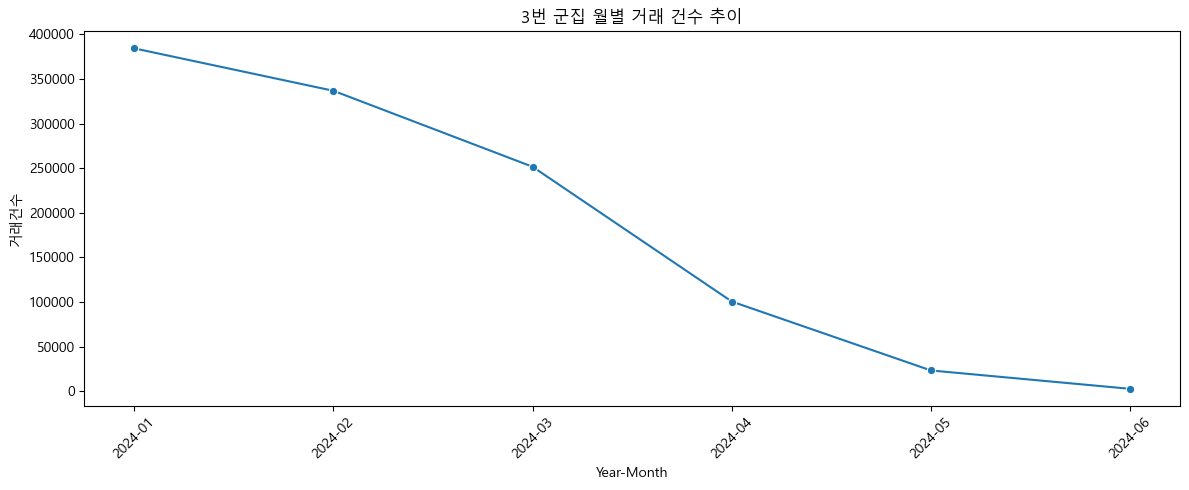

In [55]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_c3, x='year_month', y='거래건수', marker='o')

plt.title('3번 군집 월별 거래 건수 추이')
plt.xlabel('Year-Month')
plt.ylabel('거래건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

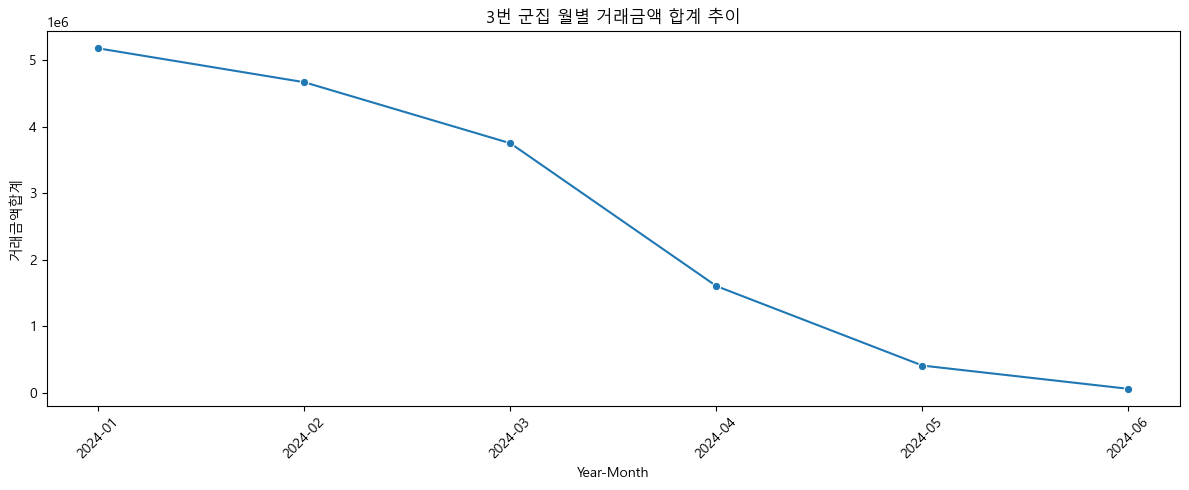

In [56]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_c3, x='year_month', y='거래금액합계', marker='o')

plt.title('3번 군집 월별 거래금액 합계 추이')
plt.xlabel('Year-Month')
plt.ylabel('거래금액합계')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
present_col = 'CARD_PRESENT_INDICATOR'

# 데이터 정리
temp = df.copy()
temp[date_col] = pd.to_datetime(temp[date_col], errors='coerce')
temp = temp.dropna(subset=[date_col])

# 3번 군집만
c3 = temp[temp[cluster_col] == 3].copy()

# 연월 생성
c3['year_month'] = c3[date_col].dt.to_period('M').astype(str)

# 월별 × 카드제시여부 거래건수
monthly_present_count = (
    c3.groupby(['year_month', present_col])
      .size()
      .reset_index(name='거래건수')
)

display(monthly_present_count)

,year_month,CARD_PRESENT_INDICATOR,거래건수
0,2024-01,Card Not Present,44952
1,2024-01,Card Present,282431
2,2024-01,Unknown,56836
3,2024-02,Card Not Present,39001
4,2024-02,Card Present,249435
5,2024-02,Unknown,48257
6,2024-03,Card Not Present,29342
7,2024-03,Card Present,186916
8,2024-03,Unknown,35291
9,2024-04,Card Not Present,11527


In [58]:
monthly_present_pivot = (
    monthly_present_count
    .pivot(index='year_month', columns=present_col, values='거래건수')
    .fillna(0)
    .astype(int)
)

display(monthly_present_pivot)

CARD_PRESENT_INDICATOR,Card Not Present,Card Present,Unknown
year_month,,,
2024-01,44952,282431,56836
2024-02,39001,249435,48257
2024-03,29342,186916,35291
2024-04,11527,75866,13148
2024-05,2732,17928,2662
2024-06,308,2200,236


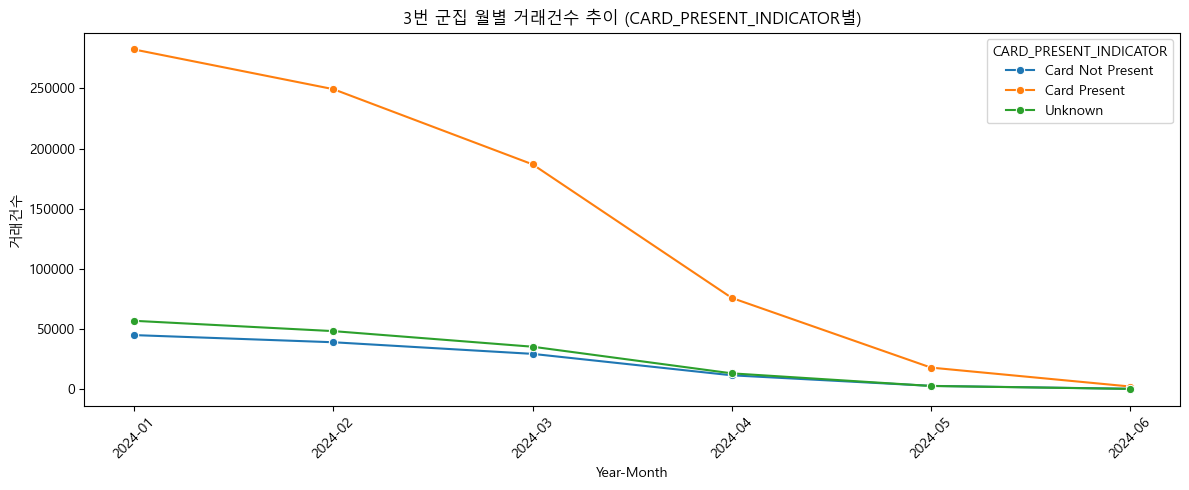

In [59]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_present_count,
    x='year_month',
    y='거래건수',
    hue=present_col,
    marker='o'
)

plt.title('3번 군집 월별 거래건수 추이 (CARD_PRESENT_INDICATOR별)')
plt.xlabel('Year-Month')
plt.ylabel('거래건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
monthly_present_ratio = (
    monthly_present_pivot.div(monthly_present_pivot.sum(axis=1), axis=0) * 100
).round(2)

display(monthly_present_ratio)

CARD_PRESENT_INDICATOR,Card Not Present,Card Present,Unknown
year_month,,,
2024-01,11.70,73.51,14.79
2024-02,11.58,74.08,14.33
2024-03,11.66,74.31,14.03
2024-04,11.46,75.46,13.08
2024-05,11.71,76.87,11.41
2024-06,11.22,80.17,8.60


--- [Cluster 3] 요일별 거래 비중 (%) ---
DayOfWeek
Monday       13.382793
Tuesday      14.255715
Wednesday    15.010809
Thursday     15.754439
Friday       16.613076
Saturday     13.916882
Sunday       11.066285
Name: proportion, dtype: float64


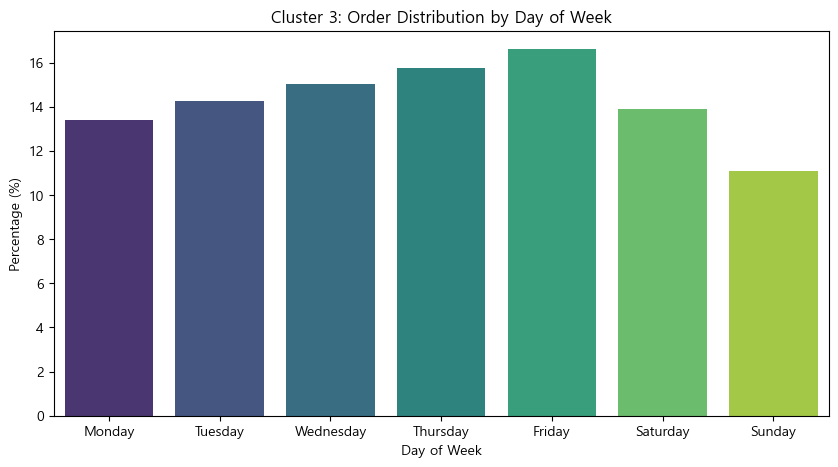

In [ ]:
# 1. 요일 순서 정의
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. 카테고리형 데이터로 변환
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=day_order, ordered=True)

# 3. 3번 군집만 떼어내서 분석
cluster_3 = df[df['CLUSTER_K4'] == 3]

# 4. 3번 군집의 요일별 거래 건수 및 비중 계산
c3_day_counts = cluster_3['DayOfWeek'].value_counts().sort_index()
c3_day_ratio = cluster_3['DayOfWeek'].value_counts(normalize=True).sort_index() * 100

print("--- [Cluster 3] 요일별 거래 비중 (%) ---")
print(c3_day_ratio)

# 5. 시각화 
plt.figure(figsize=(10, 5))
sns.barplot(x=c3_day_ratio.index, y=c3_day_ratio.values, palette='viridis')
plt.title('Cluster 3: Order Distribution by Day of Week')
plt.ylabel('Percentage (%)')
plt.xlabel('Day of Week')
plt.show()